In [1]:
import pandas as pd
import numpy as np

In [2]:

np.random.seed(42)

In [3]:
n = 200

session_id = np.arange(1,101)
user_id = np.arange(100,201)
date_range = pd.date_range('2026-02-01',periods=42)
has_widget = [0,1]
hotel_booked = [0,1]
searches = np.linspace(0,50,n) + np.random.randint(5,10,n)
revenue = np.linspace(0,200,n) + np.random.randint(0,150,n)



session_id_lst = np.random.choice(session_id,size=n)
user_id_lst = np.random.choice(user_id,size=n)
date_lst = np.random.choice(date_range,size=n)
# has_widget_lst = np.random.choice(has_widget,size=n)
hotel_booked_lst = np.random.choice(hotel_booked,size=n)

np.random.shuffle(searches)
np.random.shuffle(revenue)
# date_range

fake_df = pd.DataFrame({'session_id': session_id_lst,
                        'user_id': user_id_lst,
                        'date': date_lst,
                        # 'has_widget': has_widget_lst,
                        'hotel_booked': hotel_booked_lst,
                        'searches':searches,
                        'revenue':revenue})

fake_df['has_widget'] = np.where(fake_df['date']>='2026-02-21',1,0)

fake_df

,session_id,user_id,date,hotel_booked,searches,revenue,has_widget
0,67,157,2026-02-02,0,41.165829,97.000000,0
1,76,119,2026-02-13,1,27.849246,274.849246,0
2,26,191,2026-02-11,0,12.015075,103.437186,0
3,16,171,2026-02-23,1,20.311558,86.135678,1
4,51,160,2026-02-16,1,40.658291,186.195980,0
...,...,...,...,...,...,...,...
195,39,183,2026-02-19,1,15.035176,167.120603,0
196,67,187,2026-02-14,1,51.221106,160.206030,0
197,45,168,2026-02-26,0,47.201005,127.517588,1
198,13,133,2026-02-04,0,26.859296,316.854271,0


In [4]:
# duplicates? user_id, session_id 

fake_df.drop_duplicates(subset=['user_id','session_id'], inplace= True)

fake_df


,session_id,user_id,date,hotel_booked,searches,revenue,has_widget
0,67,157,2026-02-02,0,41.165829,97.000000,0
1,76,119,2026-02-13,1,27.849246,274.849246,0
2,26,191,2026-02-11,0,12.015075,103.437186,0
3,16,171,2026-02-23,1,20.311558,86.135678,1
4,51,160,2026-02-16,1,40.658291,186.195980,0
...,...,...,...,...,...,...,...
195,39,183,2026-02-19,1,15.035176,167.120603,0
196,67,187,2026-02-14,1,51.221106,160.206030,0
197,45,168,2026-02-26,0,47.201005,127.517588,1
198,13,133,2026-02-04,0,26.859296,316.854271,0


In [5]:
# more hotel bookings when has widget is True?

agg_df = fake_df.groupby('has_widget').agg(total_hotel_books = ('hotel_booked', 'sum'))


agg_df

,total_hotel_books
has_widget,
0,42
1,47


In [6]:
# t-test to see is there is enough evidence that the hotel books are greater 
# when the widget was active

# test

from scipy import stats

# Split conversion rates by group

control = fake_df[fake_df['has_widget']==0]['hotel_booked']
treatment = fake_df[fake_df['has_widget']==1]['hotel_booked']

# Run the test
t_stat, p_value = stats.ttest_ind(control, treatment, equal_var=False,alternative="greater")


print(f"p-value {p_value}")


p-value 0.8172480388816021


In [ ]:
# control
# treatment

3      1
5      1
10     0
12     1
14     0
      ..
191    0
192    1
193    0
197    0
199    1
Name: hotel_booked, Length: 97, dtype: int32

In [36]:
np.random.binomial(1,0.3,200)

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0])

In [35]:
np.random.binomial(1,0.2,200)

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0])

In [9]:
conversion = fake_df.groupby('has_widget').agg(
    total_bookings=('hotel_booked', 'sum'),
    total_sessions=('hotel_booked', 'count'),
).assign(conversion_rate=lambda x: x['total_bookings'] / x['total_sessions'])
print(conversion)

            total_bookings  total_sessions  conversion_rate
has_widget                                                 
0                       42             100         0.420000
1                       47              97         0.484536


In [10]:
from statsmodels.stats.power import TTestIndPower

effect_size = (treatment.mean() - control.mean()) / control.std()
power = TTestIndPower().solve_power(
    effect_size=effect_size,
    nobs1=len(control),
    alpha=0.05,
    alternative='larger'
)
print(f"Achieved power: {power:.2f}")

Achieved power: 0.23


In [41]:
required_n = TTestIndPower().solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    alternative='larger'
)

print(f"Required users per group: {required_n:.0f}")

Required users per group: 731


In [40]:
effect_size

0.13010127547006134

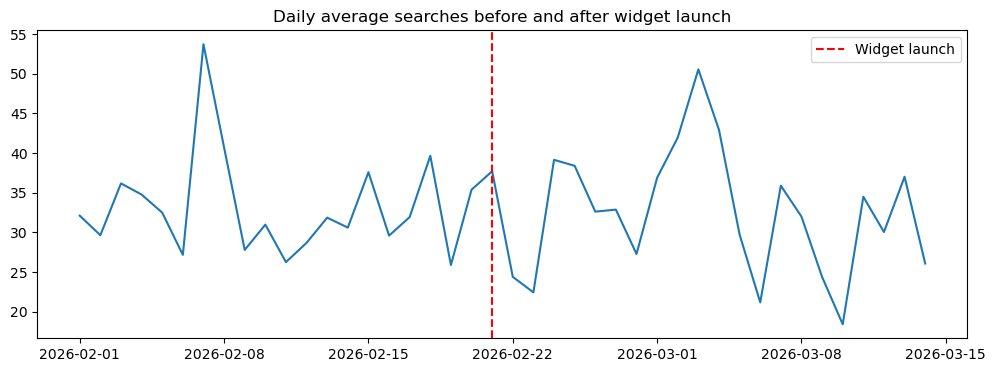

has_widget
0    31.967085
1    32.315081
Name: searches, dtype: float64


In [39]:
import matplotlib.pyplot as plt

# Daily search volume before and after launch
daily_searches = fake_df.groupby(['date', 'has_widget'])['searches'].mean().reset_index()

# Plot it
plt.figure(figsize=(12, 4))
plt.plot(daily_searches['date'], daily_searches['searches'])
plt.axvline(x=pd.Timestamp('2026-02-21'), color='red', linestyle='--', label='Widget launch')
plt.legend()
plt.title('Daily average searches before and after widget launch')
plt.show()

# Simple comparison
print(fake_df.groupby('has_widget')['searches'].mean())